✅ Successfully read ESG data from CSV
WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done

===== Group Statistics =====
    esg_level  avg_return  count
0     Low ESG   -0.036517      2
1  Medium ESG    0.030239      2
2    High ESG    0.009122      3

===== Correlation Matrix =====
            esg_score  avg_return  volatility
esg_score    1.000000    0.498455   -0.997151
avg_return   0.498455    1.000000   -0.490450
volatility  -0.997151   -0.490450    1.000000


/var/folders/ym/kqwk_mb92l9bk65_34hj03dm0000gn/T/ipykernel_20316/2022503708.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="esg_level", y="avg_return", data=group_stats, palette=palette_map)


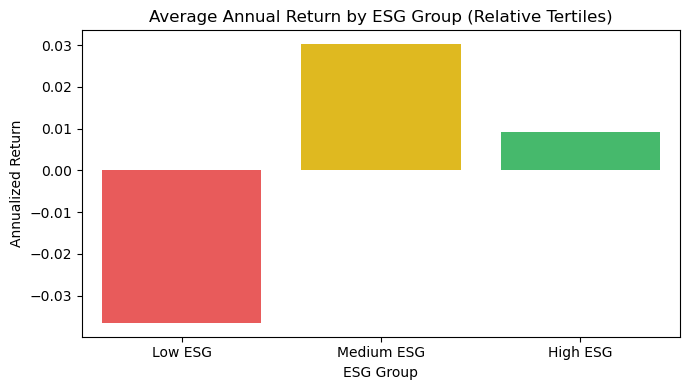

/var/folders/ym/kqwk_mb92l9bk65_34hj03dm0000gn/T/ipykernel_20316/2022503708.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="esg_level", y="avg_return", data=df_final, palette=palette_map, showmeans=True,


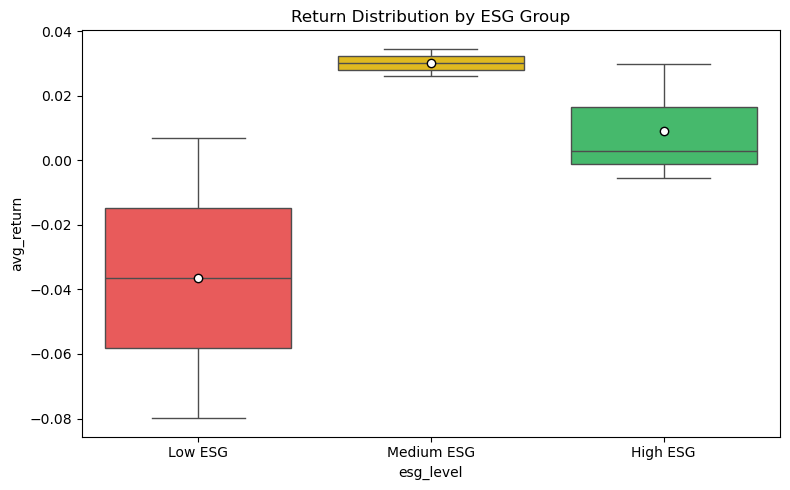

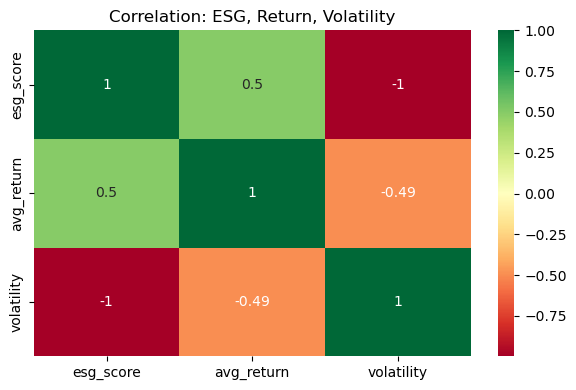

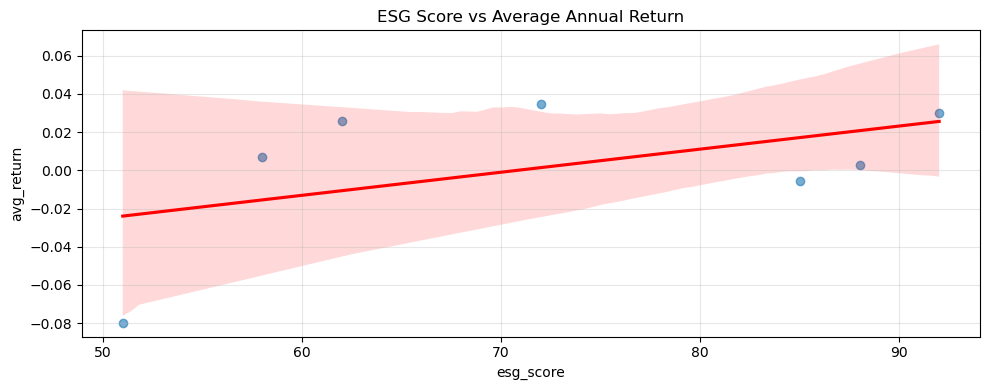


       📊 MINI ASSIGNMENT SUMMARY REPORT
1. Performance Analysis:
   - The 'Medium ESG' group had the highest average return (3.02%).
   - The 'Low ESG' group had the lowest average return (-3.65%).

2. Correlation Analysis:
   - The correlation between ESG Score and Return is 0.498.
   - Interpretation: There is a POSITIVE relationship.

3. Risk Analysis:
   - Correlation between ESG and Volatility: -0.997
   - Insight: Higher ESG is associated with LOWER volatility.

       ✅ Analysis Complete


In [2]:
# ACC102 Mini Assignment - Final Professional Version
# Data Source: WRDS Stock Returns + Local CSV ESG Data
# Student ID: 2469514
# Name: Xinqi Xue

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wrds


# Step 1: Load local ESG data from CSV
df_esg = pd.read_csv("esg_return_sample.csv")
print("✅ Successfully read ESG data from CSV")

permno_list = df_esg['permno'].unique().tolist()
permno_tuple = tuple(permno_list)


# Step 2: Connect to WRDS and download stock returns
db = wrds.Connection()

df_wrds = db.raw_sql(f"""
    SELECT permno, date, ret
    FROM crsp.msf
    WHERE permno IN {permno_tuple}
    AND date >= '2023-01-01' AND date <= '2024-12-31'
    AND ret IS NOT NULL;
""")

db.close()
df_wrds['date'] = pd.to_datetime(df_wrds['date'])


# Step 3: Aggregate monthly data to company-level annual averages
company_stats = df_wrds.groupby('permno').agg(
    avg_return=('ret', 'mean'),
    avg_volatility=('ret', 'std')
).reset_index()


# Step 4: Merge WRDS returns with ESG data
df_final = pd.merge(
    company_stats,
    df_esg[['permno', 'esg_score', 'volatility']],
    on='permno'
)


# Step 5: Classify ESG into 3 equal groups (tertiles)
df_final["esg_level"] = pd.qcut(
    df_final["esg_score"],
    q=[0, 0.33, 0.66, 1],
    labels=["Low ESG", "Medium ESG", "High ESG"]
)


# Step 6: Statistical analysis
print("\n===== Group Statistics =====")
group_stats = df_final.groupby("esg_level", observed=True).agg(
    avg_return=('avg_return', 'mean'),
    count=('permno', 'count')
).reset_index()
print(group_stats)

corr_matrix = df_final[["esg_score", "avg_return", "volatility"]].corr()
print("\n===== Correlation Matrix =====")
print(corr_matrix)

# Step 7: Visualization
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
palette_map = {
    "Low ESG": "#FF4444",
    "Medium ESG": "#FFCC00",
    "High ESG": "#33CC66"
}

# Plot 1: Bar chart
plt.figure(figsize=(7,4))
sns.barplot(x="esg_level", y="avg_return", data=group_stats, palette=palette_map)
plt.title("Average Annual Return by ESG Group (Relative Tertiles)")
plt.ylabel("Annualized Return")
plt.xlabel("ESG Group")
plt.tight_layout()
plt.savefig("1_bar_chart.png", dpi=300) # save figure to the folder
plt.show()

# Plot 2: Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x="esg_level", y="avg_return", data=df_final, palette=palette_map, showmeans=True, 
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
plt.title("Return Distribution by ESG Group")
plt.tight_layout()
plt.savefig("2_boxplot.png", dpi=300) # save figure
plt.show()

# Plot 3: Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="RdYlGn")
plt.title("Correlation: ESG, Return, Volatility")
plt.tight_layout()
plt.savefig("3_heatmap.png", dpi=300) # save figure
plt.show()

# Plot 4: Scatter plot
plt.figure(figsize=(10,4))
sns.regplot(x='esg_score', y='avg_return', data=df_final,
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title("ESG Score vs Average Annual Return")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("4_scatter.png", dpi=300) # save figure
plt.show()


# Step 8: Automated Summary & Interpretation 
print("\n" + "="*50)
print("       📊 MINI ASSIGNMENT SUMMARY REPORT")
print("="*50)

best_group = group_stats.loc[group_stats['avg_return'].idxmax()]
worst_group = group_stats.loc[group_stats['avg_return'].idxmin()]

print(f"1. Performance Analysis:")
print(f"   - The '{best_group['esg_level']}' group had the highest average return ({best_group['avg_return']:.2%}).")
print(f"   - The '{worst_group['esg_level']}' group had the lowest average return ({worst_group['avg_return']:.2%}).")

corr_val = corr_matrix.loc['esg_score', 'avg_return']
print(f"\n2. Correlation Analysis:")
print(f"   - The correlation between ESG Score and Return is {corr_val:.3f}.")
if corr_val > 0.1:
    print(f"   - Interpretation: There is a POSITIVE relationship.")
elif corr_val < -0.1:
    print(f"   - Interpretation: There is a NEGATIVE relationship.")
else:
    print(f"   - Interpretation: No significant linear relationship.")

vol_corr = corr_matrix.loc['esg_score', 'volatility']
print(f"\n3. Risk Analysis:")
print(f"   - Correlation between ESG and Volatility: {vol_corr:.3f}")
if vol_corr < 0:
    print(f"   - Insight: Higher ESG is associated with LOWER volatility.")
else:
    print(f"   - Insight: Higher ESG is associated with HIGHER volatility.")

print("\n" + "="*50)
print("       ✅ Analysis Complete")
print("="*50)